# Transportia — Modelado de la solución (Entregable 3)

**Ciencia de Datos Aplicada — ITBA**

**Pipeline de predicción de travel time y headway para colectivos del AMBA**

Este notebook presenta los resultados del pipeline modular construido para:
- Predecir el tiempo de viaje entre paradas consecutivas (travel time)
- Predecir el intervalo entre colectivos en una parada (headway)
- Analizar la eficiencia de las rutas respecto al plan GTFS
- Simular rutas alternativas evaluando impacto en travel time y headway

In [1]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from pathlib import Path

OUTPUTS = Path("../outputs")

def load_parquet(name):
    p = OUTPUTS / name
    if p.exists():
        return pd.read_parquet(p)
    print(f"⚠ {name} no encontrado. Ejecutar los scripts primero.")
    return pd.DataFrame()

print("Listo para cargar outputs.")

Listo para cargar outputs.


## Carga y preparación

Cargamos los outputs generados por los scripts 01-03 del pipeline.

In [2]:
stop_events = load_parquet("stop_events.parquet")
segments_raw = load_parquet("segments_raw.parquet")
headway_raw = load_parquet("headway_raw.parquet")
segments_feat = load_parquet("segments_features.parquet")
headway_feat = load_parquet("headway_features.parquet")

In [3]:
print("=== Resumen de datos ===")
for name, df in [("Stop Events", stop_events), ("Segments Raw", segments_raw),
                  ("Headway Raw", headway_raw), ("Segments Features", segments_feat),
                  ("Headway Features", headway_feat)]:
    if not df.empty:
        print(f"{name}: {len(df):,} filas x {df.shape[1]} columnas")
    else:
        print(f"{name}: no disponible")

=== Resumen de datos ===
Stop Events: 27,291,258 filas x 15 columnas
Segments Raw: 4,626,522 filas x 18 columnas
Headway Raw: 4,159,128 filas x 7 columnas
Segments Features: 4,625,664 filas x 27 columnas
Headway Features: 3,894,923 filas x 13 columnas


In [4]:
if not segments_feat.empty:
    print("=== Segmentos — Estadísticas ===")
    print(segments_feat[["distance_m", "travel_time_observed"]].describe())
else:
    print("No hay datos de segmentos features.")

=== Segmentos — Estadísticas ===
         distance_m  travel_time_observed
count  3.172801e+06          4.625664e+06
mean   5.307659e+02          9.841180e+01
std    1.131342e+03          1.154939e+02
min    0.000000e+00          8.000000e+00
25%    2.558937e+02          6.000000e+01
50%    3.648563e+02          6.200000e+01
75%    5.335152e+02          1.200000e+02
max    8.223473e+04          3.600000e+03


In [5]:
if not headway_feat.empty:
    print("=== Headway — Estadísticas ===")
    print(headway_feat[["headway_observed"]].describe())
else:
    print("No hay datos de headway features.")

=== Headway — Estadísticas ===
       headway_observed
count      3.894923e+06
mean       1.227108e+03
std        1.234229e+03
min        3.000000e+01
25%        3.820000e+02
50%        8.400000e+02
75%        1.618000e+03
max        7.200000e+03


## Entrenamiento

Se entrenaron dos modelos con GridSearchCV:
- **Modelo A (Travel Time):** XGBoost vs Random Forest
- **Modelo B (Headway):** Random Forest vs Gradient Boosting

In [6]:
metrics_tt_path = OUTPUTS / "metrics_travel_time.json"
metrics_hw_path = OUTPUTS / "metrics_headway.json"

if metrics_tt_path.exists():
    with open(metrics_tt_path) as f:
        metrics_tt = json.load(f)
    print("=== Travel Time Model — Métricas ===")
    df_metrics_tt = pd.DataFrame(metrics_tt["results"])
    print(df_metrics_tt.to_string(index=False))
    print(f"\nMejor modelo: {metrics_tt['best_model']}")
else:
    print("⚠ metrics_travel_time.json no encontrado.")

=== Travel Time Model — Métricas ===
                 model       MAE       RMSE        R2
               XGBoost 33.000633  65.950283  0.588398
          RandomForest 32.537954  64.401666  0.607501
       Baseline (mean) 52.317371 102.796758 -0.000008
Baseline (dist bucket) 55.069439 106.521575 -0.073791

Mejor modelo: RandomForest


In [7]:
if metrics_hw_path.exists():
    with open(metrics_hw_path) as f:
        metrics_hw = json.load(f)
    print("=== Headway Model — Métricas ===")
    df_metrics_hw = pd.DataFrame(metrics_hw["results"])
    print(df_metrics_hw.to_string(index=False))
    print(f"\nMejor modelo: {metrics_hw['best_model']}")
else:
    print("⚠ metrics_headway.json no encontrado.")

=== Headway Model — Métricas ===
           model         MAE        RMSE        R2
    RandomForest  706.102976 1057.243992  0.221393
GradientBoosting  747.924846 1085.916517  0.178588
 GTFS programado 1092.488974 1469.473689 -0.504151

Mejor modelo: RandomForest


## Métricas y visualización

Feature Importance — Travel Time Model


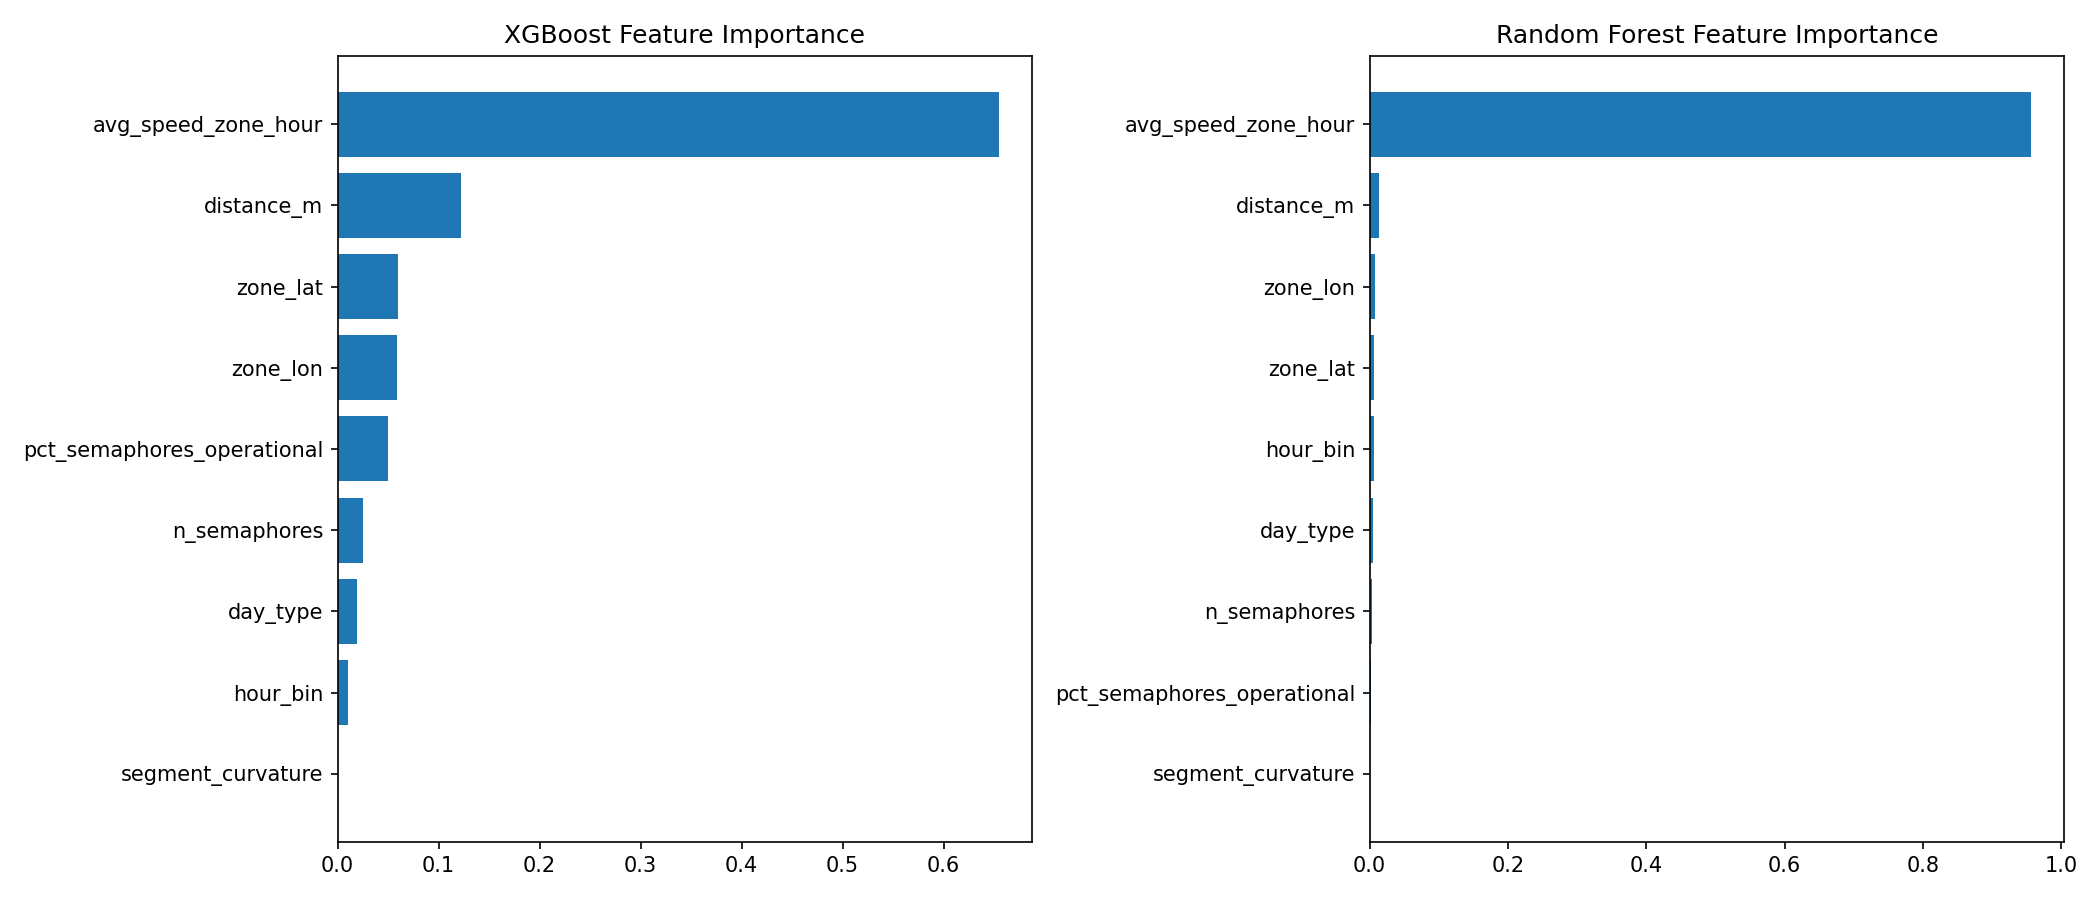

In [8]:
fi_tt_path = OUTPUTS / "feature_importance_travel_time.png"
fi_hw_path = OUTPUTS / "feature_importance_headway.png"

if fi_tt_path.exists():
    from IPython.display import Image, display
    print("Feature Importance — Travel Time Model")
    display(Image(filename=str(fi_tt_path)))
else:
    print("⚠ feature_importance_travel_time.png no encontrado.")

Feature Importance — Headway Model


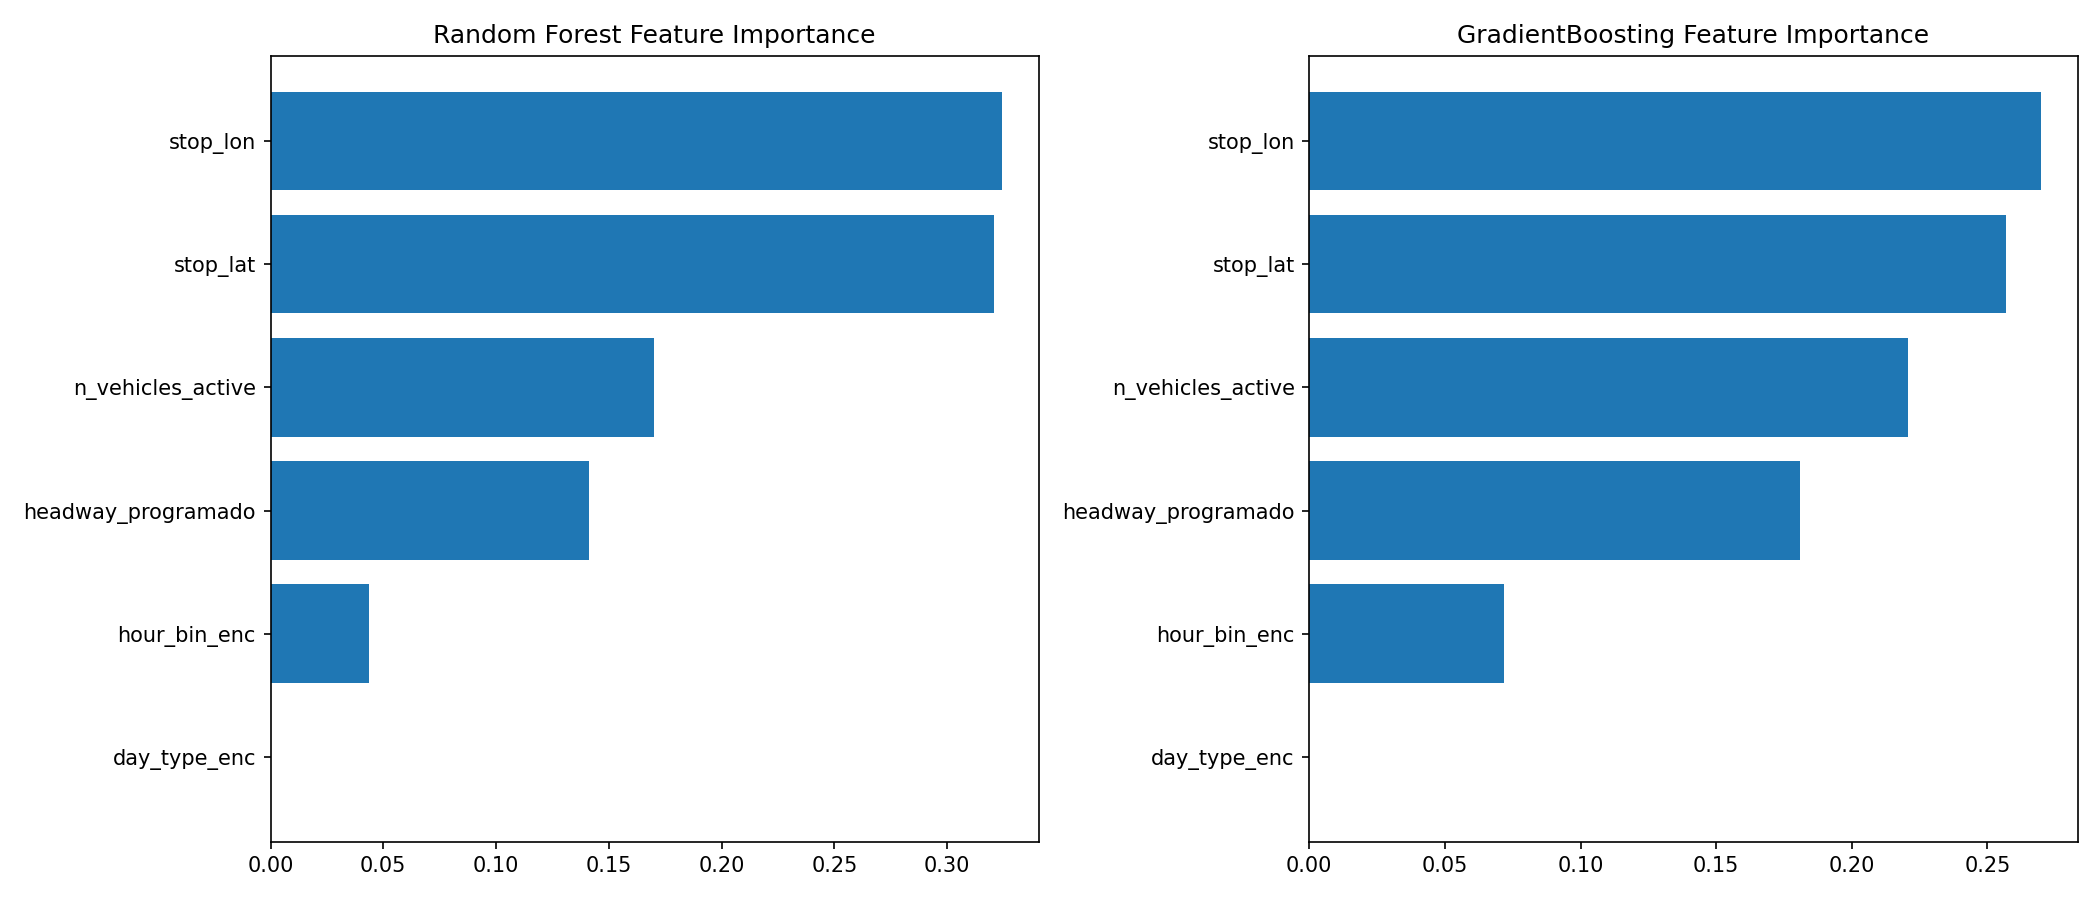

In [9]:
if fi_hw_path.exists():
    from IPython.display import Image, display
    print("Feature Importance — Headway Model")
    display(Image(filename=str(fi_hw_path)))
else:
    print("⚠ feature_importance_headway.png no encontrado.")

In [ ]:
if not segments_feat.empty and metrics_tt_path.exists():
    model_tt = joblib.load(OUTPUTS / "model_travel_time.joblib")
    features = model_tt["features"]
    feat_df = segments_feat.dropna(subset=features + ["travel_time_observed"]).copy()

    feat_df = feat_df[feat_df["travel_time_observed"] <= 900]

    hour_map = {"early_morning": 0, "morning_peak": 1, "midday": 2, "evening_peak": 3, "night": 4}
    day_map = {"weekday": 0, "weekend": 1}
    if "hour_bin" in feat_df.columns:
        feat_df["hour_bin"] = feat_df["hour_bin"].map(hour_map).fillna(2)
    if "day_type" in feat_df.columns:
        feat_df["day_type"] = feat_df["day_type"].map(day_map).fillna(0)

    sample = feat_df.sample(min(5000, len(feat_df)), random_state=42)
    X_sample = sample[features].values
    y_sample = sample["travel_time_observed"].values
    preds = model_tt["model"].predict(X_sample)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].scatter(y_sample, preds, alpha=0.3, s=5)
    max_val = 900
    axes[0].plot([0, max_val], [0, max_val], "r--", label="Identidad")
    axes[0].set_xlabel("Real (s)")
    axes[0].set_ylabel("Predicho (s)")
    axes[0].set_title("Travel Time: Real vs Predicho (sin outliers)")
    axes[0].set_xlim(0, max_val)
    axes[0].set_ylim(0, max_val)
    axes[0].legend()

    residuals = preds - y_sample
    axes[1].hist(residuals, bins=50, edgecolor="black")
    axes[1].axvline(0, color="r", linestyle="--")
    axes[1].set_xlabel("Residuo (s)")
    axes[1].set_ylabel("Frecuencia")
    axes[1].set_title("Distribucion de residuos")

    plt.tight_layout()
    plt.show()
else:
    print("No hay datos suficientes para generar scatter plot.")

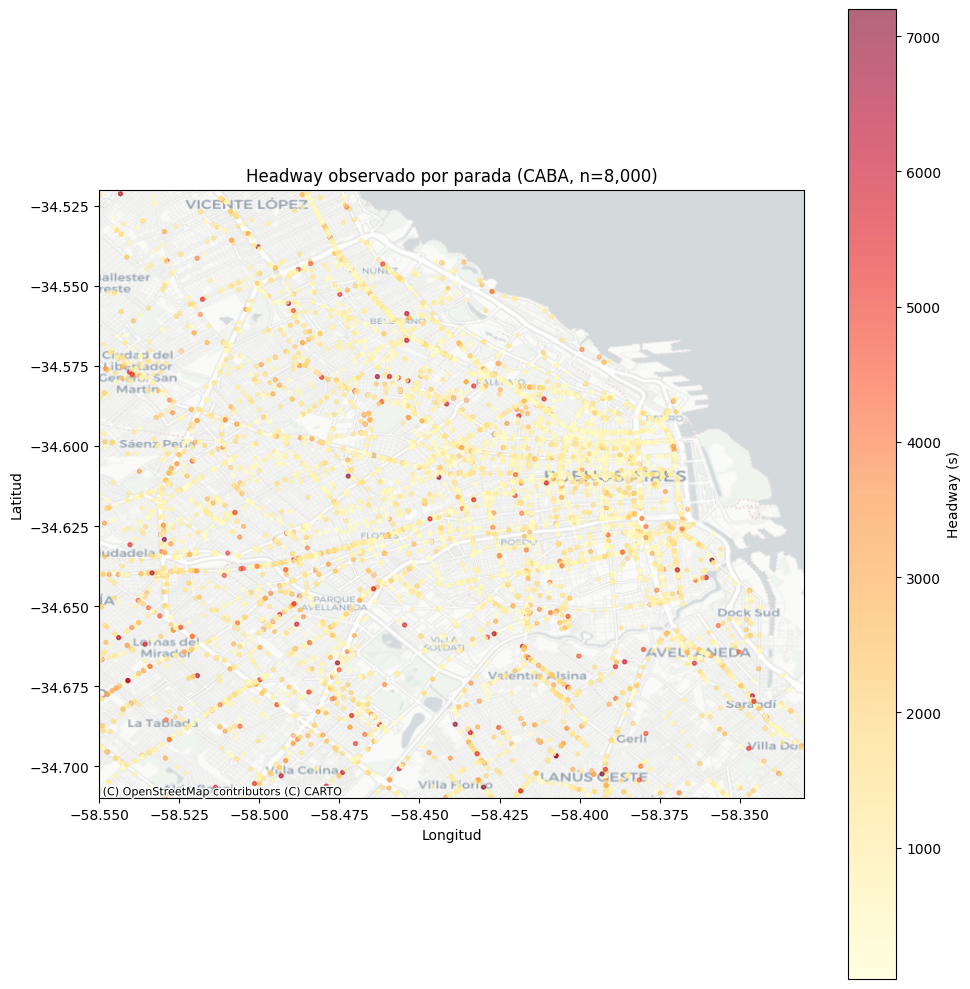

In [11]:
if not headway_feat.empty:
    hw = headway_feat.dropna(subset=["headway_observed"])
    if "stop_lat" in hw.columns and "stop_lon" in hw.columns:
        CABA_LAT = (-34.71, -34.52)
        CABA_LON = (-58.55, -58.33)
        hw_caba = hw[hw["stop_lat"].between(*CABA_LAT) & hw["stop_lon"].between(*CABA_LON)]
        fig, ax = plt.subplots(figsize=(10, 10))
        sample_hw = hw_caba.sample(min(8000, len(hw_caba)), random_state=42)
        sc = ax.scatter(
            sample_hw["stop_lon"], sample_hw["stop_lat"],
            c=sample_hw["headway_observed"], cmap="YlOrRd",
            s=8, alpha=0.6
        )
        plt.colorbar(sc, label="Headway (s)")
        ax.set_xlim(*CABA_LON)
        ax.set_ylim(*CABA_LAT)
        ax.set_xlabel("Longitud")
        ax.set_ylabel("Latitud")
        ax.set_title(f"Headway observado por parada (CABA, n={len(sample_hw):,})")
        ax.set_aspect("equal")
        try:
            import contextily as cx
            cx.add_basemap(ax, crs="EPSG:4326", source=cx.providers.CartoDB.Positron)
        except Exception:
            pass
        plt.tight_layout()
        plt.show()
    else:
        print("No hay coordenadas de parada en headway features.")
else:
    print("No hay datos de headway features.")

## Análisis de resultados

In [12]:
route_scores = load_parquet("route_scores.parquet")
if not route_scores.empty:
    print("=== Eficiencia de rutas ===")
    print(f"Rutas analizadas: {len(route_scores)}")
    print(f"\nTop 10 peores rutas:")
    cols = ["route_short_name", "spatial_deviation_m", "temporal_deviation_pct", "efficiency_score"]
    print(route_scores.head(10)[[c for c in cols if c in route_scores.columns]].to_string(index=False))
    print(f"\nTop 10 mejores rutas:")
    print(route_scores.tail(10).iloc[::-1][[c for c in cols if c in route_scores.columns]].to_string(index=False))
else:
    print("⚠ route_scores.parquet no encontrado.")

=== Eficiencia de rutas ===
Rutas analizadas: 1936

Top 10 peores rutas:
route_short_name  spatial_deviation_m  temporal_deviation_pct  efficiency_score
            103B         1.696792e+06               57.951807     848975.447787
            103B         1.696781e+06               42.289157     848813.443485
             28J         1.607584e+06              262.911647     806420.969214
             28J         1.603342e+06              198.162651     803652.745805
           R8/99         1.548911e+06              333.373494     777789.149032
             88M         1.528808e+06              333.403614     767737.820802
            195F         1.417287e+06              258.102410     711224.507976
           505R3         1.285041e+06              116.325301     643683.631391
           505R6         1.285682e+06               48.815261     643328.920774
           324T5         1.277183e+06              320.903614     641800.354462

Top 10 mejores rutas:
route_short_name  spatia

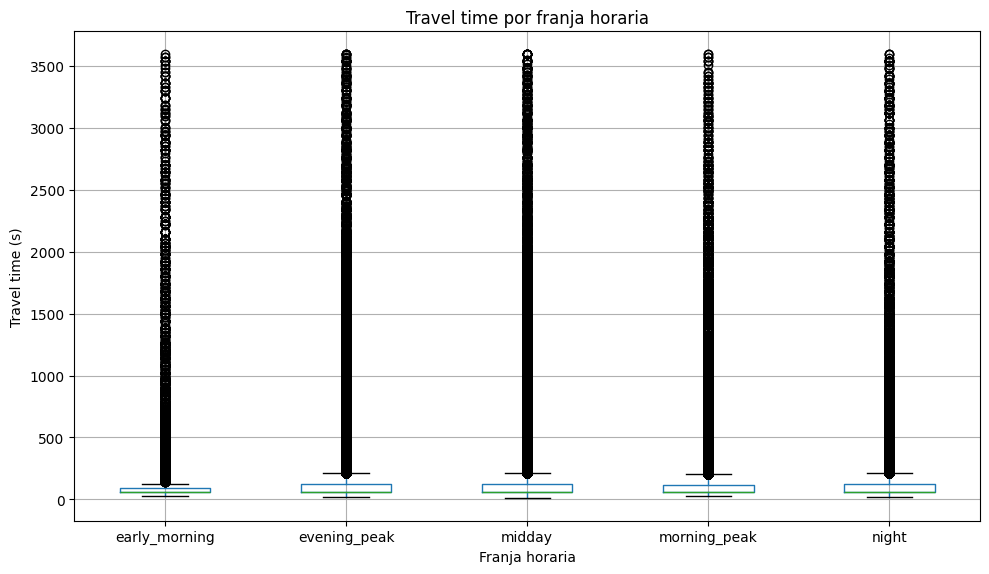

In [13]:
if not segments_feat.empty and "hour_bin" in segments_feat.columns:
    fig, ax = plt.subplots(figsize=(10, 6))
    order = ["early_morning", "morning_peak", "midday", "evening_peak", "night"]
    existing = [h for h in order if h in segments_feat["hour_bin"].unique()]
    if existing:
        segments_feat[segments_feat["hour_bin"].isin(existing)].boxplot(
            column="travel_time_observed", by="hour_bin", ax=ax
        )
        ax.set_title("Travel time por franja horaria")
        ax.set_xlabel("Franja horaria")
        ax.set_ylabel("Travel time (s)")
        plt.suptitle("")
        plt.tight_layout()
        plt.show()
    else:
        print("No hay datos de hour_bin para visualizar.")
else:
    print("No hay datos de segmentos features.")

## Simulador de rutas — Optimizacion con grafo de paradas

Identificamos zonas congestionadas en la **linea 106A** (Caballito -> Liniers) y proponemos desvios con **nuevas paradas de otras lineas** para mantener la cobertura urbana (max ~500m entre paradas).


In [ ]:
import sys, networkx as nx
from scipy.spatial import cKDTree
sys.path.insert(0, str(Path('../scripts').resolve()))
from utils import haversine_m

MAX_GAP_M = 500
MEDIAN_SPEED = 4.6

sf = load_parquet('segments_features.parquet')
if sf.empty:
    print('Run scripts 01-03 first.')
else:
    r106 = sf[(sf['route_short_name'] == '106A') & sf['stop_A_lat'].notna()]
    best_trip = r106.groupby('trip_id').size().sort_values(ascending=False).index[0]
    trip_data = r106[r106['trip_id'] == best_trip]

    stops_seq = trip_data.groupby('arrival_seq').agg(
        stop_id=('stop_id_A', 'first'), lat=('stop_A_lat', 'median'), lon=('stop_A_lon', 'median'),
    ).sort_index().reset_index(drop=True)

    seg_stats = trip_data[trip_data['next_seq'] == trip_data['arrival_seq'] + 1].groupby(
        'arrival_seq'
    ).agg(
        med_tt=('travel_time_observed', 'median'),
        med_dist=('distance_m', 'median'),
    ).sort_index().reset_index(drop=True)

    total_tt = seg_stats['med_tt'].sum()
    print(f'Linea 106A — Trip {best_trip}')
    print(f'  {len(stops_seq)} paradas, {seg_stats["med_dist"].sum():.0f}m totales')
    print(f'  Tiempo total observado: {total_tt:.0f}s ({total_tt/60:.1f} min)')

    # Build nearby stops
    all_a = sf[['stop_id_A','stop_A_lat','stop_A_lon']].dropna().drop_duplicates('stop_id_A')
    all_a.columns = ['stop_id','lat','lon']
    all_b = sf[['stop_id_B','stop_B_lat','stop_B_lon']].dropna().drop_duplicates('stop_id_B')
    all_b.columns = ['stop_id','lat','lon']
    all_stops = pd.concat([all_a, all_b]).drop_duplicates('stop_id')

    bbox_lat = (stops_seq['lat'].min()-0.015, stops_seq['lat'].max()+0.015)
    bbox_lon = (stops_seq['lon'].min()-0.015, stops_seq['lon'].max()+0.015)
    nearby = all_stops[all_stops['lat'].between(*bbox_lat) & all_stops['lon'].between(*bbox_lon)]
    stop_routes = sf.dropna(subset=['stop_A_lat']).groupby('stop_id_A')[
        'route_short_name'].apply(lambda x: list(x.unique())[:5]).to_dict()

    # Build bus graph with estimated edges
    graph_edges = sf.dropna(subset=['stop_A_lat']).groupby(['stop_id_A','stop_id_B']).agg(
        med_tt=('travel_time_observed','median'), n=('travel_time_observed','count'),
    ).reset_index()
    graph_edges = graph_edges[graph_edges['n'] >= 3]
    zone_ids = set(nearby['stop_id'])
    ze = graph_edges[graph_edges['stop_id_A'].isin(zone_ids) & graph_edges['stop_id_B'].isin(zone_ids)]

    bus_graph = nx.DiGraph()
    for _, r in ze.iterrows():
        bus_graph.add_edge(r['stop_id_A'], r['stop_id_B'], weight=r['med_tt'])

    # Add estimated edges for nearby non-route stops
    route_stop_ids = set(stops_seq['stop_id'])
    coords = np.radians(nearby[['lat','lon']].values)
    tree = cKDTree(coords)
    radius_rad = (MAX_GAP_M * 2) / 6_371_000
    pairs = tree.query_pairs(radius_rad)
    for i, j in pairs:
        s, t = nearby.iloc[i], nearby.iloc[j]
        if s['stop_id'] in route_stop_ids and t['stop_id'] in route_stop_ids:
            continue
        if not bus_graph.has_edge(s['stop_id'], t['stop_id']):
            d = haversine_m(s['lat'], s['lon'], t['lat'], t['lon'])
            est_tt = d / MEDIAN_SPEED
            bus_graph.add_edge(s['stop_id'], t['stop_id'], weight=est_tt)
            bus_graph.add_edge(t['stop_id'], s['stop_id'], weight=est_tt)

    print(f'  Grafo: {bus_graph.number_of_nodes()} nodos, {bus_graph.number_of_edges()} aristas')


In [ ]:
p90 = seg_stats['med_tt'].quantile(0.85)
mean_speed = seg_stats['med_dist'].sum() / seg_stats['med_tt'].sum()

zones = []
i = 0
while i < len(seg_stats):
    if seg_stats.iloc[i]['med_tt'] > p90:
        start = i
        while i < len(seg_stats) and seg_stats.iloc[i]['med_tt'] > p90 * 0.6:
            i += 1
        end = min(i, len(seg_stats))
        if end - start >= 1:
            zt = seg_stats.iloc[start:end]['med_tt'].sum()
            zd = seg_stats.iloc[start:end]['med_dist'].sum()
            expected = zd / mean_speed
            if zt > expected * 1.3 and zt > 120:
                zones.append({'start': start, 'end': end, 'tt': zt, 'dist': zd})
    else:
        i += 1

all_stops_map = nearby.set_index('stop_id')[['lat','lon']].to_dict('index')
proposals = []

for z in zones:
    a = stops_seq.iloc[z['start']]
    b = stops_seq.iloc[z['end']]
    try:
        path = nx.shortest_path(bus_graph, a['stop_id'], b['stop_id'], weight='weight')
        path_tt = sum(bus_graph[path[i]][path[i+1]]['weight'] for i in range(len(path)-1))
    except (nx.NetworkXNoPath, KeyError):
        path = [a['stop_id'], b['stop_id']]
        path_tt = z['tt']

    removed = [stops_seq.iloc[idx]['stop_id'] for idx in range(z['start']+1, z['end'])]
    new_stops = []
    for sid in path[1:-1]:
        info = all_stops_map.get(sid)
        if info:
            new_stops.append({'stop_id': sid, 'lat': info['lat'], 'lon': info['lon'],
                              'lines': stop_routes.get(sid, [])[:5],
                              'is_new': sid not in route_stop_ids})

    # Check gaps
    all_pts = [(a['lat'], a['lon'])]
    for ns in new_stops:
        all_pts.append((ns['lat'], ns['lon']))
    all_pts.append((b['lat'], b['lon']))

    extra = []
    for idx in range(len(all_pts)-1):
        gap = haversine_m(all_pts[idx][0], all_pts[idx][1], all_pts[idx+1][0], all_pts[idx+1][1])
        if gap > MAX_GAP_M:
            mid = ((all_pts[idx][0]+all_pts[idx+1][0])/2, (all_pts[idx][1]+all_pts[idx+1][1])/2)
            close = nearby[(abs(nearby['lat']-mid[0])<0.003) & (abs(nearby['lon']-mid[1])<0.003)
                            & (~nearby['stop_id'].isin(route_stop_ids))]
            if not close.empty:
                c = close.iloc[0]
                extra.append({'stop_id': c['stop_id'], 'lat': c['lat'], 'lon': c['lon'],
                              'lines': stop_routes.get(c['stop_id'], [])[:5], 'gap': gap})

    max_gap = max(haversine_m(all_pts[i][0], all_pts[i][1], all_pts[i+1][0], all_pts[i+1][1])
                  for i in range(len(all_pts)-1))

    proposals.append({
        'zone': f"seq {z['start']}->{z['end']}", 'stop_A': a['stop_id'], 'stop_B': b['stop_id'],
        'lat_A': a['lat'], 'lon_A': a['lon'], 'lat_B': b['lat'], 'lon_B': b['lon'],
        'original_tt': z['tt'], 'original_dist': z['dist'],
        'removed': removed, 'new_stops': new_stops, 'extra': extra,
        'alt_tt': path_tt, 'savings': max(0, z['tt'] - path_tt), 'max_gap': max_gap,
    })

    removed_str = ', '.join(removed)
    print(f"Zona {proposals[-1]['zone']}: {a['stop_id']} -> {b['stop_id']}")
    print(f"  Problema: {z['tt']:.0f}s en {z['dist']:.0f}m")
    print(f"  Eliminar: {removed_str}")
    for ns in new_stops:
        tag = '(NUEVA)' if ns['is_new'] else ''
        lines = ', '.join(ns['lines'][:3])
        print(f"  Agregar: {ns['stop_id']}{tag} [{lines}]")
    for es in extra:
        lines = ', '.join(es['lines'][:3])
        print(f"  + Intermedia: {es['stop_id']} [{lines}] (gap {es['gap']:.0f}m)")
    print(f"  Tiempo: {z['tt']:.0f}s -> {path_tt:.0f}s (ahorro {proposals[-1]['savings']:.0f}s)")
    print()

total_savings = sum(p['savings'] for p in proposals)
print(f"AHORRO TOTAL: {total_savings:.0f}s ({total_savings/60:.1f} min) — {total_savings/total_tt*100:.1f}%")


In [ ]:
fig, ax = plt.subplots(figsize=(14, 10))

ax.plot(stops_seq['lon'], stops_seq['lat'], 'b-o', markersize=3,
        linewidth=1.5, alpha=0.5, zorder=2, label='Ruta actual 106A')

for p in proposals:
    ax.plot([p['lon_A'], p['lon_B']], [p['lat_A'], p['lat_B']],
            color='red', linewidth=3, alpha=0.3, zorder=3)
    for sid in p['removed']:
        m = stops_seq[stops_seq['stop_id']==sid]
        if not m.empty:
            ax.plot(m.iloc[0]['lon'], m.iloc[0]['lat'], 'x', color='red',
                    markersize=10, markeredgewidth=2, zorder=5)

    alt_lons = [p['lon_A']] + [ns['lon'] for ns in p['new_stops']] + \
               [es['lon'] for es in p['extra']] + [p['lon_B']]
    alt_lats = [p['lat_A']] + [ns['lat'] for ns in p['new_stops']] + \
               [es['lat'] for es in p['extra']] + [p['lat_B']]
    ax.plot(alt_lons, alt_lats, 'g-', linewidth=2.5, alpha=0.7, zorder=4)

    for ns in p['new_stops']:
        if ns['is_new']:
            ax.plot(ns['lon'], ns['lat'], '*', color='limegreen', markersize=14,
                    markeredgecolor='black', markeredgewidth=0.8, zorder=6)
            ax.annotate(','.join(ns['lines'][:2]), (ns['lon'], ns['lat']),
                        fontsize=7, fontweight='bold', color='green',
                        xytext=(5, 5), textcoords='offset points', zorder=7)
    for es in p['extra']:
        ax.plot(es['lon'], es['lat'], '*', color='gold', markersize=12,
                markeredgecolor='black', markeredgewidth=0.8, zorder=6)

    mid_lon = (p['lon_A'] + p['lon_B']) / 2
    mid_lat = (p['lat_A'] + p['lat_B']) / 2
    ax.annotate(f"-{p['savings']:.0f}s", (mid_lon, mid_lat),
                fontsize=9, fontweight='bold', color='darkgreen',
                ha='center', va='bottom', zorder=8,
                bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.8))

from matplotlib.lines import Line2D
legend_items = [
    Line2D([0], [0], color='blue', marker='o', markersize=3, linewidth=1.5, alpha=0.5, label='Ruta actual 106A'),
    Line2D([0], [0], color='red', linewidth=3, alpha=0.3, label='Zona congested'),
    Line2D([0], [0], color='green', linewidth=2.5, alpha=0.7, label='Ruta propuesta'),
    Line2D([0], [0], marker='x', color='red', markersize=10, linestyle='None', markeredgewidth=2, label='Parada eliminada'),
    Line2D([0], [0], marker='*', color='limegreen', markersize=14, linestyle='None', markeredgecolor='black', label='Parada nueva (otra linea)'),
    Line2D([0], [0], marker='*', color='gold', markersize=12, linestyle='None', markeredgecolor='black', label='Parada intermedia nueva'),
]
ax.legend(handles=legend_items, loc='upper left', fontsize=8)

margin = 0.004
ax.set_xlim(stops_seq['lon'].min() - margin, stops_seq['lon'].max() + margin)
ax.set_ylim(stops_seq['lat'].min() - margin, stops_seq['lat'].max() + margin)
ax.set_aspect('equal')

try:
    import contextily as cx
    cx.add_basemap(ax, crs='EPSG:4326', source=cx.providers.CartoDB.Positron)
except Exception:
    pass

ax.set_xlabel('Longitud')
ax.set_ylabel('Latitud')
ax.set_title('Linea 106A: Propuestas de optimizacion con nuevas paradas')
plt.tight_layout()
plt.show()


In [ ]:
if proposals:
    rows = []
    for p in proposals:
        n_removed = len(p['removed'])
        n_new = len([ns for ns in p['new_stops'] if ns['is_new']])
        n_extra = len(p['extra'])
        new_lines = set()
        for ns in p['new_stops']:
            new_lines.update(ns['lines'][:2])
        for es in p['extra']:
            new_lines.update(es['lines'][:2])
        rows.append({
            'Zona': p['zone'],
            'TT original': f"{p['original_tt']:.0f}s",
            'Distancia': f"{p['original_dist']:.0f}m",
            'Paradas eliminadas': n_removed,
            'Paradas nuevas': n_new + n_extra,
            'Lineas alternativas': ', '.join(sorted(new_lines)[:5]),
            'TT alternativa': f"{p['alt_tt']:.0f}s",
            'Ahorro': f"{p['savings']:.0f}s ({p['savings']/60:.1f}min)",
        })
    summary_df = pd.DataFrame(rows)
    print('=== Resumen de propuestas ===')
    print(summary_df.to_string(index=False))
    print(f"\nAhorro total: {total_savings:.0f}s ({total_savings/60:.1f} min) — {total_savings/total_tt*100:.1f}%")
else:
    print('Sin propuestas.')


## Persistencia del modelo

Los modelos se guardan como archivos `.joblib`, permitiendo cargarlos y usarlos sin reentrenar.

In [20]:
model_tt_path = OUTPUTS / "model_travel_time.joblib"
model_hw_path = OUTPUTS / "model_headway.joblib"

if model_tt_path.exists():
    bundle_tt = joblib.load(model_tt_path)
    print(f"✅ Travel time model: {bundle_tt['model_name']}")
    print(f"   Features: {bundle_tt['features']}")
else:
    print("⚠ model_travel_time.joblib no encontrado")

if model_hw_path.exists():
    bundle_hw = joblib.load(model_hw_path)
    print(f"✅ Headway model: {bundle_hw['model_name']}")
    print(f"   Features: {bundle_hw['features']}")
else:
    print("⚠ model_headway.joblib no encontrado")

print("\nDemo de predicción sin reentrenamiento:")
if model_tt_path.exists():
    X_test = pd.DataFrame([{
        "distance_m": 800,
        "zone_lat": -34.60,
        "zone_lon": -58.39,
        "hour_bin": 1,
        "day_type": 0,
        "avg_speed_zone_hour": 180,
        "n_semaphores": 3,
        "pct_semaphores_operational": 0.8,
        "segment_curvature": 1.0,
    }])
    X_test = X_test[[c for c in bundle_tt["features"] if c in X_test.columns]]
    print(f"  Segmento demo (800m, hora pico): {bundle_tt['model'].predict(X_test)[0]:.0f}s")

✅ Travel time model: RandomForest
   Features: ['distance_m', 'zone_lat', 'zone_lon', 'hour_bin', 'day_type', 'avg_speed_zone_hour', 'n_semaphores', 'pct_semaphores_operational', 'segment_curvature']
✅ Headway model: RandomForest
   Features: ['stop_lat', 'stop_lon', 'hour_bin_enc', 'day_type_enc', 'n_vehicles_active', 'headway_programado']

Demo de predicción sin reentrenamiento:
  Segmento demo (800m, hora pico): 182s


/home/kerty/Projects/transportia/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(


## Reflexiones finales

### Limitaciones
- **Datos de 24h únicamente:** Una sola jornada no captura la variabilidad semanal ni estacional.
- **Cobertura GPS:** Solo ~64% de los pings tenían `stop_id`, lo que reduce las observaciones por segmento.
- **Generalización de segmentos:** El simulador predice para segmentos nuevos usando features físicos, pero la confianza disminuye en zonas sin datos observados.
- **Semáforos solo CABA:** Las features de semáforos no aplican para segmentos en el conurbano.
- **route_id matching:** El 70% de los pings del feed simple eran huérfanos respecto al GTFS; el feed FULL mitigó esto con `trip_id` directo.

### Mejoras con más datos
- Recolectar datos de múltiples días/semanas para capturar variabilidad temporal.
- Incorporar datos de sube/baja de pasajeros para modelar demanda.
- Agregar features de tráfico en tiempo real (velocidad por tramo).
- Modelar time-series para capturar tendencias y estacionalidad.

### Aplicabilidad real
- El modelo de travel time permite evaluar rutas alternativas sin necesidad de prueba piloto.
- El modelo de headway identifica paradas con peor frecuencia, priorizando intervenciones.
- El análisis de eficiencia cuantifica la brecha entre plan y realidad por ruta.

### Conexión con Entregable 4
- Los modelos `.joblib` están listos para ser integrados en una API (FastAPI/Flask).
- El pipeline modular permite automatizar el reentrenamiento periódico.
- El simulador puede exponerse como endpoint para consultas de planificación.